In [2]:
import numpy as np

def structure_function_QU(Q, U, R_list, *,
                          min_pI=None,
                          bin_width=0.5,
                          max_pairs=None,
                          random_seed=0):
    """
    Compute polarization-angle structure function D_phi(R) from Q,U maps.

    Parameters
    ----------
    Q, U : 2D np.ndarray
        Stokes Q and U maps, same shape (Ny, Nx).
    R_list : array-like
        Radii (pixel separations) at which to compute the structure function.
        Can be ints or floats (in pixels).
    min_pI : float or None
        Optional threshold on polarized intensity pI = sqrt(Q^2+U^2).
        Pixels with pI < min_pI are masked out.
        If None, no threshold besides finite values.
    bin_width : float
        Radial bin half-width in pixels. Pairs with distance d satisfying
        |d - R| <= bin_width are included for that R.
    max_pairs : int or None
        If set, randomly subsample at most this many valid pairs per R
        to reduce compute cost on large maps.
    random_seed : int
        RNG seed for subsampling.

    Returns
    -------
    out : dict
        Keys:
          'R'      : np.ndarray of R values (same order as input)
          'Dphi'   : np.ndarray of D_phi(R)
          'Npairs' : np.ndarray of number of pairs used per R
    """
    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)
    if Q.shape != U.shape or Q.ndim != 2:
        raise ValueError("Q and U must be 2D arrays with the same shape.")

    Ny, Nx = Q.shape

    # Polarized intensity and normalized Stokes
    pI = np.sqrt(Q*Q + U*U)

    valid = np.isfinite(Q) & np.isfinite(U) & np.isfinite(pI) & (pI > 0)
    if min_pI is not None:
        valid &= (pI >= float(min_pI))

    # Normalized Stokes: q = Q/pI, u = U/pI
    q = np.full_like(Q, np.nan, dtype=float)
    u = np.full_like(U, np.nan, dtype=float)
    q[valid] = Q[valid] / pI[valid]
    u[valid] = U[valid] / pI[valid]

    R_arr = np.asarray(R_list, dtype=float)
    Dphi = np.full_like(R_arr, np.nan, dtype=float)
    Npairs = np.zeros_like(R_arr, dtype=int)

    rng = np.random.default_rng(random_seed)

    # Precompute coordinate grids for valid pixels
    y_idx, x_idx = np.where(valid)
    n_valid = len(y_idx)
    if n_valid < 2:
        raise ValueError("Not enough valid pixels to compute structure function.")

    # Helper to accumulate pair contributions for a given integer shift (dy, dx)
    def accumulate_shift(dy, dx):
        # Overlapping slices for shift (dy, dx)
        y1s = slice(max(0, dy), min(Ny, Ny + dy))
        y2s = slice(max(0, -dy), min(Ny, Ny - dy))
        x1s = slice(max(0, dx), min(Nx, Nx + dx))
        x2s = slice(max(0, -dx), min(Nx, Nx - dx))

        q1 = q[y1s, x1s]; u1 = u[y1s, x1s]
        q2 = q[y2s, x2s]; u2 = u[y2s, x2s]

        m = np.isfinite(q1) & np.isfinite(u1) & np.isfinite(q2) & np.isfinite(u2)
        if not np.any(m):
            return None  # no pairs

        dq = (q1[m] - q2[m])
        du = (u1[m] - u2[m])
        # D_phi contribution per pair:
        # 1/4 * (dq^2 + du^2)
        contrib = 0.25 * (dq*dq + du*du)
        return contrib

    # For each R, build all integer shifts (dx,dy) whose distance falls in the bin
    for i, R in enumerate(R_arr):
        if R < 0:
            continue

        # Search shifts in a square that covers the ring
        rmax = int(np.ceil(R + bin_width))
        shifts = []
        for dy in range(-rmax, rmax + 1):
            for dx in range(-rmax, rmax + 1):
                if dx == 0 and dy == 0:
                    continue
                d = np.hypot(dx, dy)
                if abs(d - R) <= bin_width:
                    shifts.append((dy, dx))

        if len(shifts) == 0:
            continue

        all_contrib = []
        for dy, dx in shifts:
            contrib = accumulate_shift(dy, dx)
            if contrib is not None and contrib.size > 0:
                all_contrib.append(contrib)

        if len(all_contrib) == 0:
            continue

        contrib_vec = np.concatenate(all_contrib)
        n = contrib_vec.size

        if (max_pairs is not None) and (n > max_pairs):
            idx = rng.choice(n, size=int(max_pairs), replace=False)
            contrib_vec = contrib_vec[idx]
            n = contrib_vec.size

        Dphi[i] = np.nanmean(contrib_vec)
        Npairs[i] = n

    return {"R": R_arr, "Dphi": Dphi, "Npairs": Npairs}


# --------------------
# Example usage:
# --------------------
# Q, U are 2D arrays (Ny, Nx)
# R_list = np.arange(1, 51)  # radii in pixels
# out = structure_function_QU(Q, U, R_list, min_pI=3.0, bin_width=0.5, max_pairs=200000)
# print(out["R"])
# print(out["Dphi"])
# print(out["Npairs"])


In [4]:
def pol_vec_components(p, psi):
    # psi in degrees
    psi = psi * np.pi/180 + np.pi/2
    vx = p*np.cos(psi)
    vy = p*np.sin(psi)
    return vx, vy

Filename: data/NGC7331_D.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  STOKES I      1 PrimaryHDU    1636   (94, 94)   float64   
  1  ERROR I       1 ImageHDU        19   (94, 94)   float64   
  2  STOKES Q      1 ImageHDU        19   (94, 94)   float64   
  3  ERROR Q       1 ImageHDU        19   (94, 94)   float64   
  4  STOKES U      1 ImageHDU        19   (94, 94)   float64   
  5  ERROR U       1 ImageHDU        19   (94, 94)   float64   
  6  IMAGE MASK    1 ImageHDU        62   (94, 94)   float64   
  7  PERCENT POL    1 ImageHDU        19   (94, 94)   float64   
  8  DEBIASED PERCENT POL    1 ImageHDU        19   (94, 94)   float64   
  9  ERROR PERCENT POL    1 ImageHDU        19   (94, 94)   float64   
 10  POL ANGLE     1 ImageHDU        19   (94, 94)   float64   
 11  ROTATED POL ANGLE    1 ImageHDU        19   (94, 94)   float64   
 12  ERROR POL ANGLE    1 ImageHDU        19   (94, 94)   float64   
 13  POL FLUX      1 ImageHDU        19   (94,


HDU names:
0 STOKES I (94, 94)
1 ERROR I (94, 94)
2 STOKES Q (94, 94)
3 ERROR Q (94, 94)
4 STOKES U (94, 94)
5 ERROR U (94, 94)
6 IMAGE MASK (94, 94)
7 PERCENT POL (94, 94)
8 DEBIASED PERCENT POL (94, 94)
9 ERROR PERCENT POL (94, 94)
10 POL ANGLE (94, 94)
11 ROTATED POL ANGLE (94, 94)
12 ERROR POL ANGLE (94, 94)
13 POL FLUX (94, 94)
14 ERROR POL FLUX (94, 94)
15 DEBIASED POL FLUX (94, 94)
16 POL DATA (8836,)
17 FINAL POL DATA (212,)


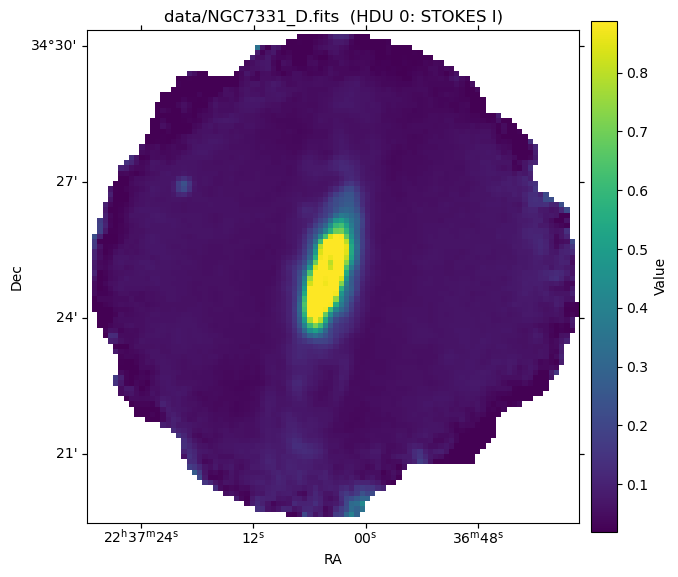

In [59]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

fits_path = "data/NGC7331_D.fits" 

# -------------------------
# 1) Открываем и смотрим HDU
# -------------------------
hdul = fits.open(fits_path)
hdul.info()

# Печать имён расширений (если есть)
print("\nHDU names:")
for i, h in enumerate(hdul):
    print(i, h.name, h.data.shape if h.data is not None else None)

# -------------------------
# 2) Берём первый 2D image HDU и строим карту
# -------------------------
img_hdu_index = None
for i, h in enumerate(hdul):
    if h.data is None:
        continue
    if h.data.ndim >= 2:
        img_hdu_index = i
        break

if img_hdu_index is None:
    raise ValueError("Не нашёл ни одного HDU с 2D данными для отображения.")

hdu = hdul[img_hdu_index]
data = hdu.data

# Если данные 3D/4D — возьмём первый слой (часто бывает (stokes, y, x) или (y, x, ...))
if data.ndim > 2:
    # максимально безопасно: сплющим до (y,x), выбирая первые индексы по лишним осям
    slicer = (0,) * (data.ndim - 2) + (slice(None), slice(None))
    data2d = data[slicer]
else:
    data2d = data

# WCS (если есть)
wcs = None
try:
    wcs = WCS(hdu.header).celestial
except Exception:
    wcs = None

# Робастные пределы (игнорируем NaN)
finite = np.isfinite(data2d)
vmin, vmax = np.nanpercentile(data2d[finite], [5, 99]) if np.any(finite) else (None, None)

plt.figure(figsize=(7, 6))
if wcs is not None:
    ax = plt.subplot(111, projection=wcs)
    im = ax.imshow(data2d, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
else:
    ax = plt.gca()
    im = ax.imshow(data2d, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xlabel("X (pix)")
    ax.set_ylabel("Y (pix)")

plt.colorbar(im, ax=ax, pad=0.02, label="Value")
plt.title(f"{fits_path}  (HDU {img_hdu_index}: {hdu.name})")
plt.tight_layout()
plt.show()

hdul.close()

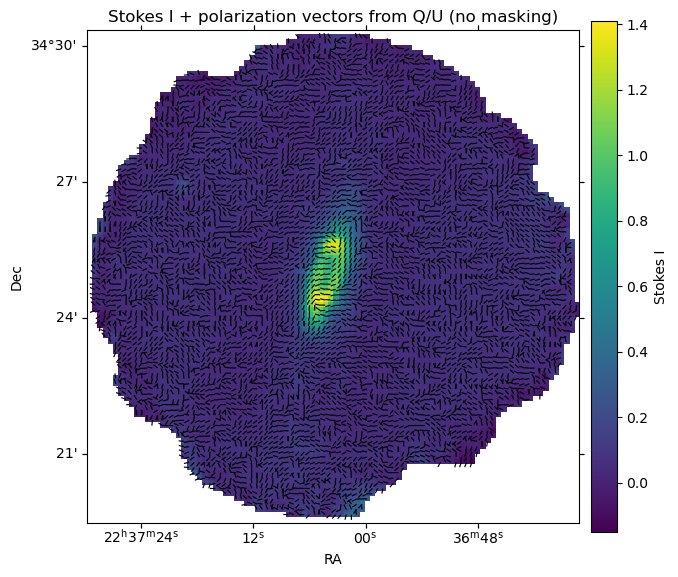

In [66]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

def pol_vec_components(p, psi):
    # psi in degrees
    psi = psi * np.pi/180 + np.pi/2
    vx = p*np.cos(psi)
    vy = p*np.sin(psi)
    return vx, vy

path = "data/NGC7331_D.fits"

with fits.open(path) as hdul:
    I   = hdul["STOKES I"].data
    Q   = hdul["STOKES Q"].data
    U   = hdul["STOKES U"].data
    wcs = WCS(hdul["STOKES I"].header).celestial

# angle from Q/U
psi_deg = np.degrees(0.5 * np.arctan2(U, Q) + np.pi/2) 

# polarized intensity (used as vector length)
P = np.sqrt(Q**2 + U**2)

# vector components
u, v = pol_vec_components(1, psi_deg)

plt.figure(figsize=(7, 6))
ax = plt.subplot(111, projection=wcs)
im = ax.imshow(I, origin="lower")
ax.quiver(u, v,
          angles='xy', scale_units='xy', scale=1,
          headwidth=0, headlength=0, headaxislength=0)

plt.colorbar(im, ax=ax, pad=0.02, label="Stokes I")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Stokes I + polarization vectors from Q/U (no masking)")
plt.tight_layout()
plt.show()

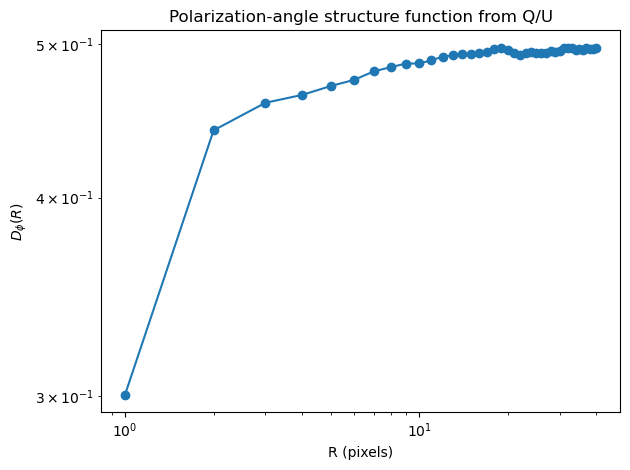

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

path = "data/NGC7331_D.fits"
with fits.open(path) as hdul:
    Q = hdul["STOKES Q"].data
    U = hdul["STOKES U"].data

# радиусы в пикселях (для 94x94 разумно до ~30-40)
R_list = np.arange(1, 41)

out = structure_function_QU(
    Q, U, R_list,
    min_pI=None,      # можно позже поставить порог
    bin_width=0.5,
    max_pairs=None    # можно поставить, если будет долго
)

R = out["R"]
D = out["Dphi"]
N = out["Npairs"]

# plot (только валидные)
m = np.isfinite(D) & (N > 0) & (R > 0) & (D > 0)
Rv = R[m]
Dv = D[m]

plt.figure()
plt.loglog(Rv, Dv, marker="o", linestyle="-")
plt.xlabel("R (pixels)")
plt.ylabel(r"$D_\phi(R)$")
plt.title("Polarization-angle structure function from Q/U")
plt.tight_layout()
plt.show()

Shapes: (277, 300) (277, 300) (277, 300)


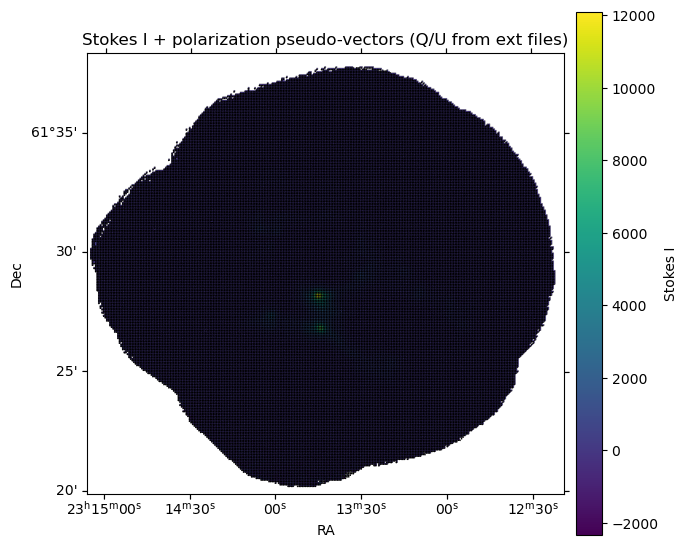

In [72]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

def pol_vec_components(p, psi):
    # psi in degrees
    psi = psi * np.pi/180 + np.pi/2
    vx = p*np.cos(psi)
    vy = p*np.sin(psi)
    return vx, vy

path_I = "data/iext_cal_beam_2d.fits"
path_Q = "data/qext_cal_beam_2d.fits"
path_U = "data/uext_cal_beam_2d.fits"

# --- read I + WCS ---
with fits.open(path_I) as hdul:
    I = hdul[0].data

# --- read Q, U (PRIMARY) ---
with fits.open(path_Q) as hdul:
    Q = hdul[0].data

with fits.open(path_U) as hdul:
    U = hdul[0].data

# (если вдруг размеры не совпадают — это сразу увидишь тут)
print("Shapes:", I.shape, Q.shape, U.shape)

# --- angle from Q/U (E-vector). НЕ добавляй +90 тут ---
psi_deg = np.degrees(0.5 * np.arctan2(U, Q))

# --- pseudo-vectors: only direction (p=1 everywhere) ---
u, v = pol_vec_components(1.0, psi_deg)

plt.figure(figsize=(7, 6))
ax = plt.subplot(111, projection=wcs)
im = ax.imshow(I, origin="lower")

ax.quiver(
    u, v,
    angles='xy', scale_units='xy', scale=1,
    headwidth=0, headlength=0, headaxislength=0,
    pivot="mid", width=0.003, color="k"
)

plt.colorbar(im, ax=ax, pad=0.02, label="Stokes I")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Stokes I + polarization pseudo-vectors (Q/U from ext files)")
plt.tight_layout()
plt.show()

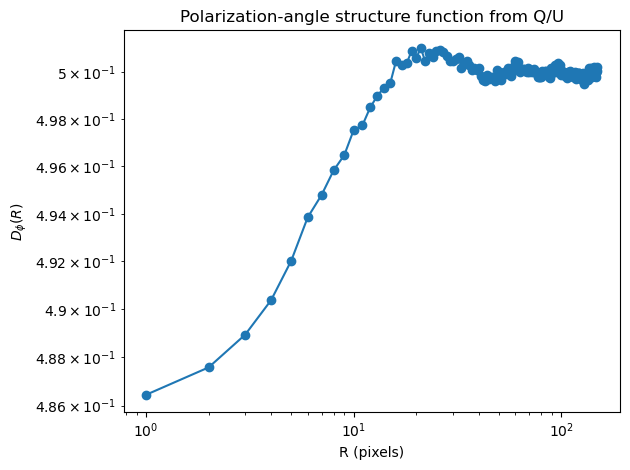

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# радиусы в пикселях (для 94x94 разумно до ~30-40)
R_list = np.arange(1, 150)

out = structure_function_QU(
    Q, U, R_list,
    min_pI=None,      # можно позже поставить порог
    bin_width=0.5,
    max_pairs=None    # можно поставить, если будет долго
)

R = out["R"]
D = out["Dphi"]
N = out["Npairs"]

# plot (только валидные)
m = np.isfinite(D) & (N > 0) & (R > 0) & (D > 0)
Rv = R[m]
Dv = D[m]

plt.figure()
plt.loglog(Rv, Dv, marker="o", linestyle="-")
plt.xlabel("R (pixels)")
plt.ylabel(r"$D_\phi(R)$")
plt.title("Polarization-angle structure function from Q/U")
plt.tight_layout()
plt.show()

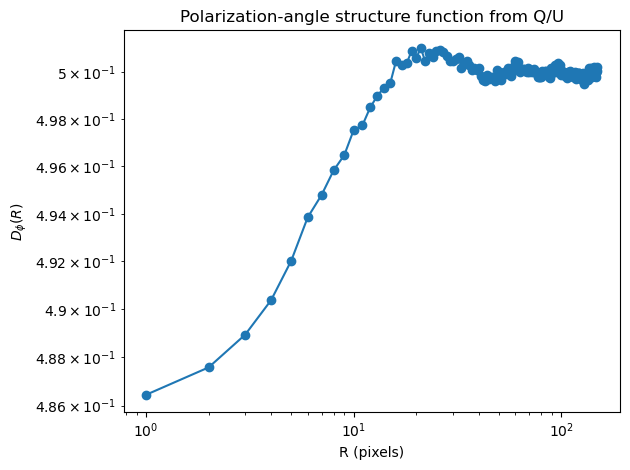

In [74]:
plt.figure()
plt.loglog(R, D, marker="o", linestyle="-")
plt.xlabel("R (pixels)")
plt.ylabel(r"$D_\phi(R)$")
plt.title("Polarization-angle structure function from Q/U")
plt.tight_layout()
plt.show()

Filename: data/uext_cal_beam_2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     581   (300, 277)   float64   
  1  VARIANCE      1 ImageHDU        56   (300, 277)   float64   
  2  QUALITY       1 ImageHDU        55   (300, 277)   uint8   

HDU names:
0 PRIMARY (277, 300)
1 VARIANCE (277, 300)
2 QUALITY (277, 300)


Set OBSGEO-B to    19.822839 from OBSGEO-[XYZ].
Set OBSGEO-H to     4120.022 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


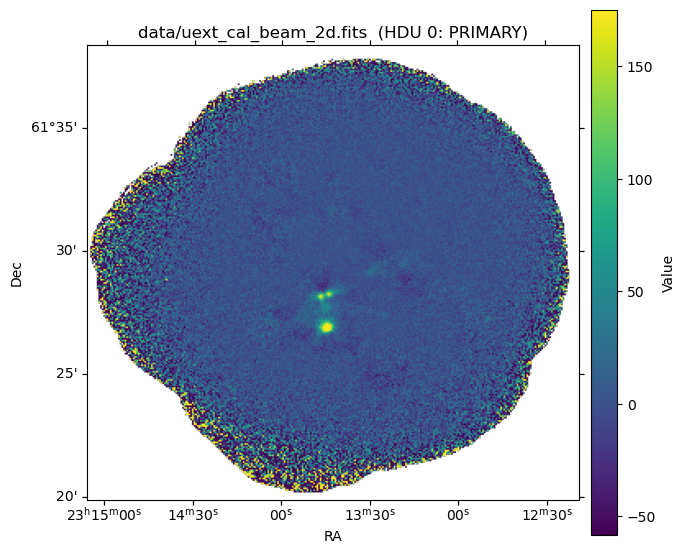

In [69]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

fits_path = "data/uext_cal_beam_2d.fits" 

# -------------------------
# 1) Открываем и смотрим HDU
# -------------------------
hdul = fits.open(fits_path)
hdul.info()

# Печать имён расширений (если есть)
print("\nHDU names:")
for i, h in enumerate(hdul):
    print(i, h.name, h.data.shape if h.data is not None else None)

# -------------------------
# 2) Берём первый 2D image HDU и строим карту
# -------------------------
img_hdu_index = None
for i, h in enumerate(hdul):
    if h.data is None:
        continue
    if h.data.ndim >= 2:
        img_hdu_index = i
        break

if img_hdu_index is None:
    raise ValueError("Не нашёл ни одного HDU с 2D данными для отображения.")

hdu = hdul[img_hdu_index]
data = hdu.data

# Если данные 3D/4D — возьмём первый слой (часто бывает (stokes, y, x) или (y, x, ...))
if data.ndim > 2:
    # максимально безопасно: сплющим до (y,x), выбирая первые индексы по лишним осям
    slicer = (0,) * (data.ndim - 2) + (slice(None), slice(None))
    data2d = data[slicer]
else:
    data2d = data

# WCS (если есть)
wcs = None
try:
    wcs = WCS(hdu.header).celestial
except Exception:
    wcs = None

# Робастные пределы (игнорируем NaN)
finite = np.isfinite(data2d)
vmin, vmax = np.nanpercentile(data2d[finite], [5, 99]) if np.any(finite) else (None, None)

plt.figure(figsize=(7, 6))
if wcs is not None:
    ax = plt.subplot(111, projection=wcs)
    im = ax.imshow(data2d, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
else:
    ax = plt.gca()
    im = ax.imshow(data2d, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xlabel("X (pix)")
    ax.set_ylabel("Y (pix)")

plt.colorbar(im, ax=ax, pad=0.02, label="Value")
plt.title(f"{fits_path}  (HDU {img_hdu_index}: {hdu.name})")
plt.tight_layout()
plt.show()

hdul.close()